In [1]:
# Repository-relative input and output paths.
from pathlib import Path
from itertools import combinations
import itertools
import warnings

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu, pearsonr, wilcoxon
from statsmodels.stats.multitest import multipletests

PROJECT_ROOT = Path.cwd().resolve()
for _candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (_candidate / "workspace" / "Source_Data.xlsx").exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError(
        "workspace/Source_Data.xlsx was not found. Run the notebook from inside the repository."
    )

WORKSPACE_DIR = PROJECT_ROOT / "workspace"
SOURCE_DATA_PATH = WORKSPACE_DIR / "Source_Data.xlsx"
FIGURES_DIR = WORKSPACE_DIR / "figures"
FIGURES_R3_DIR = WORKSPACE_DIR / "figures_R3"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_R3_DIR.mkdir(parents=True, exist_ok=True)

# Compatibility path used by cells retained from the supplied notebook.
clean_data_path = WORKSPACE_DIR.as_posix().rstrip("/") + "/"

warnings.filterwarnings("ignore")


In [2]:
bands = ['beta1','high_gamma','hgb1']
reading_name_list = ['covert',"overt"]
HS_list = [45,47,48,50,54,71,73,76,78]


In [3]:
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['font.size'] = 6

plt.rcParams['axes.unicode_minus'] = False 


# Fig. 5k


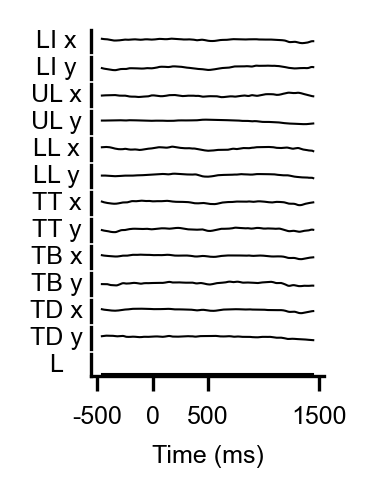

In [4]:
plot_df = pd.read_excel(SOURCE_DATA_PATH, sheet_name="Fig. 5k")

matplotlib.rcParams["font.family"] = "Arial"
matplotlib.rcParams["font.size"] = 6

feature_names = [
    "LI_x", "LI_y", "UL_x", "UL_y", "LL_x", "LL_y",
    "TT_x", "TT_y", "TB_x", "TB_y", "TD_x", "TD_y", "L",
]
display_labels = [
    "LI x", "LI y", "UL x", "UL y", "LL x", "LL y",
    "TT x", "TT y", "TB x", "TB y", "TD x", "TD y", "L",
]

fig, axes = plt.subplots(13, 1, figsize=(1, 1.5), dpi=300)
for index, (feature, display_label) in enumerate(zip(feature_names, display_labels)):
    axis = axes[index]
    axis.plot(plot_df["Time (ms)"], plot_df[feature], color="black", linewidth=0.5)
    axis.set_yticks([])
    axis.set_ylabel(display_label, rotation="horizontal", labelpad=10)
    axis.yaxis.set_label_coords(-0.15, 0)
    axis.set_ylim((-1.2, 1.2) if feature == "L" else (-5, 5))
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    if index < len(feature_names) - 1:
        axis.set_xticks([])
        axis.spines["bottom"].set_visible(False)
    else:
        axis.set_xticks([-500, 0, 500, 1500])
        axis.set_xlabel("Time (ms)")

plt.tight_layout()
plt.savefig(
    FIGURES_R3_DIR / "Fig. 5k.pdf",
    dpi=300,
    transparent=True,
    bbox_inches="tight",
)
plt.show()


# Fig. 5l–m


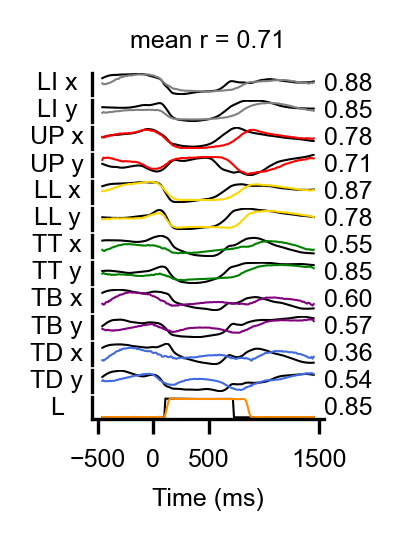

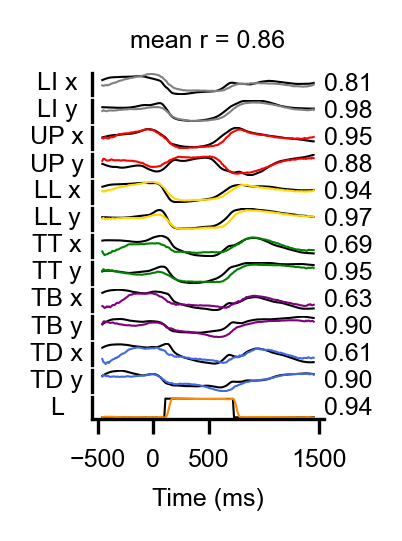

In [5]:
plt.rcdefaults()
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

colors = [
    "grey", "grey", "red", "red", "gold", "gold", "green",
    "green", "purple", "purple", "royalblue", "royalblue", "darkorange",
]
feature_names = [
    "LI_x", "LI_y", "UP_x", "UP_y", "LL_x", "LL_y",
    "TT_x", "TT_y", "TB_x", "TB_y", "TD_x", "TD_y", "L",
]
display_labels = [
    "LI x", "LI y", "UP x", "UP y", "LL x", "LL y",
    "TT x", "TT y", "TB x", "TB y", "TD x", "TD y", "L",
]

for sheet_name in ("Fig. 5l", "Fig. 5m"):
    plot_df = pd.read_excel(SOURCE_DATA_PATH, sheet_name=sheet_name)
    time_ms = plot_df["Time (ms)"].to_numpy()
    fig, axes = plt.subplots(13, 1, figsize=(1, 1.5), dpi=300)
    correlations = []

    for index, (feature, display_label, color) in enumerate(
        zip(feature_names, display_labels, colors)
    ):
        real = plot_df[f"{feature}_real"].to_numpy()
        predicted = plot_df[f"{feature}_pred"].to_numpy()
        correlation, _ = pearsonr(real, predicted)
        correlations.append(correlation)

        axis = axes[index]
        axis.plot(time_ms, real, color="black", linewidth=0.5)
        axis.plot(time_ms, predicted, color=color, linewidth=0.5)
        axis.text(1.0, 0.5, f"{correlation:.2f}", transform=axis.transAxes, va="center")
        axis.set_ylabel(display_label, rotation="horizontal", labelpad=10)
        axis.yaxis.set_label_coords(-0.15, 0)
        axis.set_yticks([])
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
        if index < len(feature_names) - 1:
            axis.set_xticks([])
            axis.spines["bottom"].set_visible(False)
        else:
            axis.set_xticks([-500, 0, 500, 1500])
            axis.set_xlabel("Time (ms)")
            axis.set_ylim(-1.2, 1.2)

    axes[0].set_title(f"mean r = {np.mean(correlations):.2f}", fontsize=6)
    plt.tight_layout()
    plt.savefig(
        FIGURES_R3_DIR / f"{sheet_name}.pdf",
        dpi=300,
        transparent=True,
        bbox_inches="tight",
    )
    plt.show()


# Fig. 5o

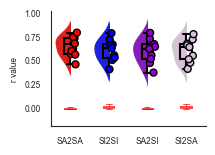

Group statistics (median, IQR, sample size):
Task: SI2SI | Median: 0.624781217445644 | Q1: 0.525805435755007 | Q3: 0.664284663638084 | N: 9
Task: SI2SA | Median: 0.636357178387075 | Q1: 0.508483291542531 | Q3: 0.67178925630158 | N: 9
Task: SA2SI | Median: 0.617831620627131 | Q1: 0.513338326052557 | Q3: 0.668041635496215 | N: 9
Task: SA2SA | Median: 0.67385776594038 | Q1: 0.562910812912536 | Q3: 0.732847346281798 | N: 9

Kruskal-Wallis H-test: H-statistic = 1.5945945945945965, p-value = 0.6606160793380977
No significant difference found between groups.

Comparison with chance level:
SI2SI | Mann-Whitney U = 81.0, p = 0.00041229480206169127
SI2SA | Mann-Whitney U = 81.0, p = 0.00041229480206169127
SA2SI | Mann-Whitney U = 81.0, p = 0.00041229480206169127
SA2SA | Mann-Whitney U = 81.0, p = 0.00041229480206169127


In [6]:
matplotlib.rcParams['font.sans-serif'] = ['Arial']
matplotlib.rcParams['font.size'] = 6

# =====================================================
# Read the Source Data workbook.
# =====================================================

source_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Fig. 5o"
)

mean_acc_df = source_df[
    source_df["Type"] == "Observed"
].copy()

chance_mean_acc_df = source_df[
    source_df["Type"] == "Chance"
].copy()

mean_acc_df = mean_acc_df.rename(
    columns={
        "Subject": "HS",
        "Task": "task",
        "Correlation (r)": "acc"
    }
)

chance_mean_acc_df = chance_mean_acc_df.rename(
    columns={
        "Subject": "HS",
        "Task": "task",
        "Correlation (r)": "acc"
    }
)

palette = {
    'SA2SA': 'r',
    'SA2SI': '#9402D3',
    'SI2SI': 'b',
    'SI2SA': '#D8BFD8'
}

# =====================================================
# Create the plot.
# =====================================================

order = ["SA2SA", "SI2SI", "SA2SI", "SI2SA"]

iris = mean_acc_df

plt.figure(figsize=(2, 1.5))
sns.set_style('white')

ax = sns.violinplot(
    x="task",
    y="acc",
    data=iris,
    order=order,
    dodge=False,
    palette=palette,
    scale="width",
    inner=None,
    linewidth=1
)

sns.despine()
plt.legend([], [], frameon=False)
plt.ylim(-0.2, 1.02)

for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(
        Rectangle(
            (x0, y0),
            width / 2,
            height,
            transform=ax.transData
        )
    )
    violin.set_edgecolor(None)

sns.boxplot(
    x="task",
    y="acc",
    data=iris,
    order=order,
    saturation=1,
    showfliers=False,
    width=0.3,
    ax=ax,
    boxprops={
        'zorder': 3,
        'facecolor': 'none',
        'edgecolor': 'black'
    },
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'},
    medianprops={'color': 'black'}
)

sns.boxplot(
    x="task",
    y="acc",
    data=chance_mean_acc_df,
    order=order,
    saturation=1,
    showfliers=False,
    width=0.3,
    ax=ax,
    boxprops={
        'zorder': 3,
        'facecolor': 'none',
        'edgecolor': 'red',
        'linewidth': 0.5
    },
    whiskerprops={
        'color': 'red',
        'linewidth': 0.5
    },
    capprops={
        'color': 'red',
        'linewidth': 0.5
    },
    medianprops={
        'color': 'red',
        'linewidth': 0.5
    }
)

old_len_collections = len(ax.collections)

sns.stripplot(
    x="task",
    y="acc",
    data=iris,
    order=order,
    palette=palette,
    dodge=False,
    ax=ax,
    size=5,
    edgecolor='black',
    linewidth=1
)

for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))

ax.set_ylabel("r value")
ax.set_xlabel("")

plt.savefig(
    clean_data_path + "figures_R3/Fig. 5o.pdf",
    transparent=True,
    format="pdf",
    bbox_inches='tight'
)

plt.show()

# =====================================================
# Calculate statistical tests.
# =====================================================

tasks = mean_acc_df['task'].unique()

print("Group statistics (median, IQR, sample size):")
for task in tasks:
    group_data = mean_acc_df.loc[
        mean_acc_df['task'] == task,
        'acc'
    ]

    median = group_data.median()
    q1 = group_data.quantile(0.25)
    q3 = group_data.quantile(0.75)
    sample_size = len(group_data)

    print(
        f"Task: {task} | "
        f"Median: {median} | "
        f"Q1: {q1} | "
        f"Q3: {q3} | "
        f"N: {sample_size}"
    )

grouped_data = [
    mean_acc_df.loc[
        mean_acc_df['task'] == task,
        'acc'
    ]
    for task in tasks
]

kruskal_stat, kruskal_p = kruskal(*grouped_data)

print(
    f"\nKruskal-Wallis H-test: "
    f"H-statistic = {kruskal_stat}, "
    f"p-value = {kruskal_p}"
)

if kruskal_p < 0.05:

    pairwise_p_values = []
    task_pairs = list(combinations(tasks, 2))

    for task1, task2 in task_pairs:

        data1 = mean_acc_df.loc[
            mean_acc_df['task'] == task1,
            'acc'
        ]

        data2 = mean_acc_df.loc[
            mean_acc_df['task'] == task2,
            'acc'
        ]

        if len(data1) == len(data2):
            _, p_value = wilcoxon(
                data1,
                data2,
                alternative='two-sided'
            )
            pairwise_p_values.append(p_value)
        else:
            print(
                f"Warning: {task1} vs {task2} "
                f"have unmatched sample sizes."
            )
            pairwise_p_values.append(1.0)

    reject, corrected_p_values, _, _ = multipletests(
        pairwise_p_values,
        method='fdr_bh'
    )

    print("\nPairwise Wilcoxon tests (FDR corrected):")

    for i, (task1, task2) in enumerate(task_pairs):

        print(
            f"{task1} vs {task2} | "
            f"raw p = {pairwise_p_values[i]:.4f} | "
            f"FDR p = {corrected_p_values[i]:.4f} | "
            f"Significant = {reject[i]}"
        )

else:
    print("No significant difference found between groups.")

print("\nComparison with chance level:")

for task in mean_acc_df['task'].unique():

    observed = mean_acc_df.loc[
        mean_acc_df['task'] == task,
        'acc'
    ].tolist()

    if task in chance_mean_acc_df['task'].values:

        chance = chance_mean_acc_df.loc[
            chance_mean_acc_df['task'] == task,
            'acc'
        ].tolist()

        if len(observed) > 0 and len(chance) > 0:

            stat, p_value = mannwhitneyu(
                observed,
                chance
            )

            print(
                f"{task} | "
                f"Mann-Whitney U = {stat}, "
                f"p = {p_value}"
            )

        else:
            print(
                f"{task} | Empty group, test skipped."
            )

    else:
        print(
            f"{task} | No chance-level data."
        )


In [7]:
def violin_boxplot_with_chance(mean_acc_df, chance_mean_acc_df, group, band, order, palette, figsize):
    print('\n--------------------------')
    print(band)
    print(group)

    iris = mean_acc_df
    # print(iris)

    # Create the violin plot.
    plt.figure(figsize=figsize)
    sns.set_style('white')
    ax = sns.violinplot(
        x="task", y="acc", data=iris, order=order, dodge=False,
        palette=palette, scale="width", inner=None, linewidth=1
    )

    # Apply the final plot formatting.
    sns.despine()
    plt.legend([], [], frameon=False)
    plt.ylim(-0.2, 1.02)

    # Clip each violin to show one half of the distribution.
    for violin in ax.collections:
        bbox = violin.get_paths()[0].get_extents()
        x0, y0, width, height = bbox.bounds
        violin.set_clip_path(
            plt.Rectangle(
                (x0, y0),
                width / 2,
                height,
                transform=ax.transData
            )
        )
        violin.set_edgecolor(None)

    # Overlay boxplots for observed decoding performance.
    sns.boxplot(
        x="task", y="acc", data=iris, order=order,
        saturation=1, showfliers=False, width=0.3,
        ax=ax,
        boxprops={'zorder': 3, 'facecolor': 'none', 'edgecolor': 'black'},
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'},
        medianprops={'color': 'black'}
    )

    # Overlay boxplots for chance-level performance.
    sns.boxplot(
        x="task", y="acc", data=chance_mean_acc_df, order=order,
        saturation=1, showfliers=False, width=0.3,
        ax=ax,
        boxprops={
            'zorder': 3,
            'facecolor': 'none',
            'edgecolor': 'red',
            'linewidth': 0.5
        },
        whiskerprops={
            'color': 'red',
            'linewidth': 0.5
        },
        capprops={
            'color': 'red',
            'linewidth': 0.5
        },
        medianprops={
            'color': 'red',
            'linewidth': 0.5
        }
    )

    old_len_collections = len(ax.collections)

    # Overlay individual participant values.
    sns.stripplot(
        x="task", y="acc", data=iris,
        order=order, palette=palette,
        dodge=False, ax=ax,
        size=5, edgecolor='black', linewidth=1
    )

    # Shift individual data points slightly to the right.
    for dots in ax.collections[old_len_collections:]:
        dots.set_offsets(
            dots.get_offsets() + np.array([0.12, 0])
        )

    ax.set_ylabel("r value")
    ax.set_xlabel("")

    plt.savefig(
        fig_save_path,
        transparent=True,
        format="pdf",
        bbox_inches='tight'
    )

    plt.show()


    # Report descriptive statistics for each group.
    tasks = mean_acc_df['task'].unique()

    print("Group statistics (median, IQR, sample size):")

    for task in tasks:
        group_data = mean_acc_df[
            mean_acc_df['task'] == task
        ]['acc']

        median = group_data.median()
        q1 = group_data.quantile(0.25)
        q3 = group_data.quantile(0.75)
        sample_size = len(group_data)

        print(
            f"Task: {task} | "
            f"Median: {median:.4f} | "
            f"Q1: {q1:.4f} | "
            f"Q3: {q3:.4f} | "
            f"N: {sample_size}"
        )

    # ==================================================
    # 1. Compare groups.
    # ==================================================

    n_groups = len(tasks)
    print(f"\nNumber of groups: {n_groups}")

    if n_groups == 2:

        # Compare two paired groups with the Wilcoxon signed-rank test.
        t1, t2 = tasks

        data1 = mean_acc_df[
            mean_acc_df['task'] == t1
        ]['acc']

        data2 = mean_acc_df[
            mean_acc_df['task'] == t2
        ]['acc']

        if len(data1) == len(data2):

            stat, p_value = wilcoxon(
                data1,
                data2,
                alternative='two-sided'
            )

            print(
                f"Wilcoxon signed-rank test "
                f"({t1} vs {t2}): "
                f"statistic={stat:.4f}, "
                f"p-value={p_value:.4g}"
            )

        else:

            print(
                f"⚠️ Unequal sample sizes "
                f"({len(data1)} vs {len(data2)}), "
                f"cannot perform paired Wilcoxon test."
            )

    else:

        # Compare multiple groups with the Kruskal-Wallis test.
        grouped_data = [
            mean_acc_df[
                mean_acc_df['task'] == t
            ]['acc']
            for t in tasks
        ]

        kw_stat, kw_p = kruskal(*grouped_data)

        print(
            f"Kruskal–Wallis test: "
            f"H = {kw_stat:.4f}, "
            f"p = {kw_p:.4g}"
        )

        if kw_p < 0.05:

            print(
                "\nPairwise Wilcoxon signed-rank tests "
                "(Benjamini–Hochberg corrected):"
            )

            pairwise_p = []
            task_pairs = list(combinations(tasks, 2))
            valid_pairs = []

            for t1, t2 in task_pairs:

                d1 = mean_acc_df[
                    mean_acc_df['task'] == t1
                ]['acc']

                d2 = mean_acc_df[
                    mean_acc_df['task'] == t2
                ]['acc']

                # Run paired Wilcoxon tests only for groups with matching sample sizes.
                if len(d1) == len(d2):

                    _, p = wilcoxon(
                        d1,
                        d2,
                        alternative='two-sided'
                    )

                    pairwise_p.append(p)
                    valid_pairs.append((t1, t2))

                else:

                    print(
                        f"⚠️ {t1} vs {t2}: "
                        f"unequal sample sizes, skipped."
                    )

            if pairwise_p:

                reject, p_corr, _, _ = multipletests(
                    pairwise_p,
                    method='fdr_bh'
                )

                for (t1, t2), p, pc, sig in zip(
                    valid_pairs,
                    pairwise_p,
                    p_corr,
                    reject
                ):

                    print(
                        f"{t1} vs {t2}: "
                        f"raw p = {p:.4g}, "
                        f"BH-corrected p = {pc:.4g}, "
                        f"significant = {sig}"
                    )

            else:

                print(
                    "No valid paired comparisons "
                    "because of unequal sample sizes."
                )

        else:

            print(
                "No significant differences "
                "among groups (Kruskal–Wallis test)."
            )

    # ==================================================
    # 2. Compare each group with chance level.
    # ==================================================

    print("\nChance-level comparisons (Mann–Whitney U):")

    for task in tasks:

        a = mean_acc_df[
            mean_acc_df['task'] == task
        ]['acc'].tolist()

        b = chance_mean_acc_df[
            chance_mean_acc_df['task'] == task
        ]['acc'].tolist()

        if len(a) and len(b):

            stat, p_value = mannwhitneyu(
                a,
                b,
                alternative='two-sided'
            )

            print(
                f"{task}: "
                f"U = {stat:.4f}, "
                f"p = {p_value:.4g}"
            )

        else:

            print(
                f"⚠️ {task}: "
                f"insufficient data for "
                f"Mann–Whitney U test."
            )


# Fig. 5n, Ext. Fig. 9c


--------------------------
beta1
sig_elecs_infer


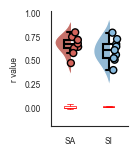

Group statistics (median, IQR, sample size):
Task: SI | Median: 0.6040 | Q1: 0.5187 | Q3: 0.6682 | N: 9
Task: SA | Median: 0.6740 | Q1: 0.6252 | Q3: 0.7144 | N: 9

Number of groups: 2
Wilcoxon signed-rank test (SI vs SA): statistic=3.0000, p-value=0.01953

Chance-level comparisons (Mann–Whitney U):
SI: U = 81.0000, p = 0.0004123
SA: U = 81.0000, p = 0.0004123



--------------------------
high_gamma
sig_elecs_infer


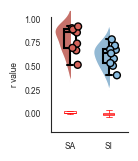

Group statistics (median, IQR, sample size):
Task: SI | Median: 0.6338 | Q1: 0.5311 | Q3: 0.6745 | N: 9
Task: SA | Median: 0.8542 | Q1: 0.6912 | Q3: 0.8864 | N: 9

Number of groups: 2
Wilcoxon signed-rank test (SI vs SA): statistic=0.0000, p-value=0.003906

Chance-level comparisons (Mann–Whitney U):
SI: U = 81.0000, p = 0.0004123
SA: U = 81.0000, p = 0.0004123


In [8]:
group = 'sig_elecs_infer'
for band in ['beta1','high_gamma']:
    order = ["SA", "SI"]
    palette = {'SA':'#D5645B',
               'SI':'#88BBDF'}
    figsize = (1, 1.5)
    
    # =====================================================
    # Read the Source Data workbook.
    # =====================================================

    sheet_name = {
        "beta1": "Fig. 5n",
        "high_gamma": "Ext. Fig. 9c"
    }[band]

    source_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )

    mean_acc_df = (
        source_df[source_df["Type"] == "Observed"]
        .rename(columns={
            "Subject": "HS",
            "Task": "task",
            "Correlation (r)": "acc"
        })
    )

    chance_mean_acc_df = (
        source_df[source_df["Type"] == "Chance"]
        .rename(columns={
            "Subject": "HS",
            "Task": "task",
            "Correlation (r)": "acc"
        })
    )
    
    fig_save_path = clean_data_path + f"figures_R3/{sheet_name}.pdf"

    violin_boxplot_with_chance(mean_acc_df,chance_mean_acc_df,group,band,order,palette,figsize)


# Fig. 5q, Ext. Fig. 9e


--------------------------
beta1
sig_elecs_infer


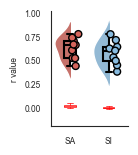

Group statistics (median, IQR, sample size):
Task: SI | Median: 0.5982 | Q1: 0.4913 | Q3: 0.6390 | N: 9
Task: SA | Median: 0.6590 | Q1: 0.5203 | Q3: 0.7012 | N: 9

Number of groups: 2
Wilcoxon signed-rank test (SI vs SA): statistic=2.0000, p-value=0.01172

Chance-level comparisons (Mann–Whitney U):
SI: U = 81.0000, p = 0.0004123
SA: U = 81.0000, p = 0.0004123



--------------------------
high_gamma
sig_elecs_infer


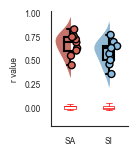

Group statistics (median, IQR, sample size):
Task: SI | Median: 0.6270 | Q1: 0.4991 | Q3: 0.6470 | N: 9
Task: SA | Median: 0.6865 | Q1: 0.6001 | Q3: 0.7424 | N: 9

Number of groups: 2
Wilcoxon signed-rank test (SI vs SA): statistic=0.0000, p-value=0.003906

Chance-level comparisons (Mann–Whitney U):
SI: U = 81.0000, p = 0.0004123
SA: U = 81.0000, p = 0.0004123


In [9]:
group = 'sig_elecs_infer'
for band in ['beta1','high_gamma']:
    order = ["SA", "SI"]
    palette = {'SA':'#D5645B',
               'SI':'#88BBDF'}
    figsize = (1, 1.5)
    
    # =====================================================
    # Read the Source Data workbook.
    # =====================================================

    sheet_name = {
        "beta1": "Fig. 5q",
        "high_gamma": "Ext. Fig. 9e"
    }[band]

    source_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )

    mean_acc_df = (
        source_df[source_df["Type"] == "Observed"]
        .rename(columns={
            "Subject": "HS",
            "Task": "task",
            "Correlation (r)": "acc"
        })
    )

    chance_mean_acc_df = (
        source_df[source_df["Type"] == "Chance"]
        .rename(columns={
            "Subject": "HS",
            "Task": "task",
            "Correlation (r)": "acc"
        })
    )
    
    fig_save_path = clean_data_path + f"figures_R3/{sheet_name}.pdf"

    violin_boxplot_with_chance(mean_acc_df,chance_mean_acc_df,group,band,order,palette,figsize)


# Ext. Fig. 8e


--------------------------
beta1
modal_specific


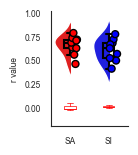

Group statistics (median, IQR, sample size):
Task: SI | Median: 0.6236 | Q1: 0.5197 | Q3: 0.6795 | N: 9
Task: SA | Median: 0.6835 | Q1: 0.6250 | Q3: 0.7157 | N: 9

Number of groups: 2
Wilcoxon signed-rank test (SI vs SA): statistic=1.0000, p-value=0.007812

Chance-level comparisons (Mann–Whitney U):
SI: U = 81.0000, p = 0.0004123
SA: U = 81.0000, p = 0.0004123


In [10]:
group = 'modal_specific'
band = 'beta1'
sheet_name = 'Ext. Fig. 8e'

order = ["SA", "SI"]  # Display the groups in the specified order.
palette = {'SA':'r',
           'SI':'b'}
figsize = (1, 1.5)

# =====================================================
# Read the Source Data workbook.
# =====================================================

source_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name=sheet_name
)

mean_acc_df = (
    source_df[source_df["Type"] == "Observed"]
    .rename(columns={
        "Subject": "HS",
        "Task": "task",
        "Correlation (r)": "acc"
    })
)

chance_mean_acc_df = (
    source_df[source_df["Type"] == "Chance"]
    .rename(columns={
        "Subject": "HS",
        "Task": "task",
        "Correlation (r)": "acc"
    })
)

fig_save_path = clean_data_path + f"figures_R3/{sheet_name}.pdf"
violin_boxplot_with_chance(mean_acc_df,chance_mean_acc_df,group,band,order,palette,figsize)


# Ext. Fig. 8g-h

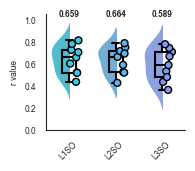

Summary statistics
L1SO: median=0.659, IQR=[0.520, 0.727], n=9
L2SO: median=0.664, IQR=[0.525, 0.717], n=9
L3SO: median=0.589, IQR=[0.480, 0.710], n=9

Wilcoxon signed-rank tests
  L1SO vs L2SO: p = 0.0547 ns
  L1SO vs L3SO: p = 0.0039 **
  L2SO vs L3SO: p = 0.0039 **


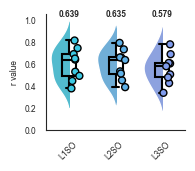

Summary statistics
L1SO: median=0.639, IQR=[0.491, 0.689], n=9
L2SO: median=0.635, IQR=[0.512, 0.659], n=9
L3SO: median=0.579, IQR=[0.478, 0.609], n=9

Wilcoxon signed-rank tests
  L1SO vs L2SO: p = 0.8203 ns
  L1SO vs L3SO: p = 0.0039 **
  L2SO vs L3SO: p = 0.0039 **


In [11]:
band = 'beta1'
sheet_dict = {
    'overt':"Ext. Fig. 8g",
    'covert':"Ext. Fig. 8h",
}
for task in sheet_dict.keys():
    sheet_name = sheet_dict[task]

    # =====================================================
    # Read the Source Data workbook.
    # =====================================================

    source_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )

    mean_acc_df = (
        source_df.rename(columns={
            "Subject": "HS",
            "Condition": "group",
            "Correlation (r)": "acc"
        })
    )

    # =====================================================
    # Create the plot.
    # =====================================================

    group_order = ["L1SO", "L2SO", "L3SO"]
    x_tick = ["L1SO", "L2SO", "L3SO"]

    palette = [
        "#3DC9E3",
        "#5FB1E8",
        "#7F9BED"
    ]

    plt.figure(figsize=(1.8, 1.5))
    sns.set_style("white")

    ax = sns.violinplot(
        x="group",
        y="acc",
        data=mean_acc_df,
        order=group_order,
        palette=palette,
        scale="width",
        inner=None,
        linewidth=1
    )

    sns.despine()

    # Draw the half-violin distribution.
    for violin in ax.collections:
        bbox = violin.get_paths()[0].get_extents()
        x0, y0, width, height = bbox.bounds
        violin.set_clip_path(
            plt.Rectangle(
                (x0, y0),
                width / 2,
                height,
                transform=ax.transData
            )
        )
        violin.set_edgecolor(None)

    # Overlay the boxplot.
    sns.boxplot(
        x="group",
        y="acc",
        data=mean_acc_df,
        order=group_order,
        width=0.3,
        showfliers=False,
        saturation=1,
        ax=ax,
        boxprops=dict(
            zorder=3,
            facecolor="none",
            edgecolor="black"
        ),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black")
    )

    # Plot individual participant values.
    old_len = len(ax.collections)

    sns.stripplot(
        x="group",
        y="acc",
        data=mean_acc_df,
        order=group_order,
        palette=palette,
        size=5,
        edgecolor="black",
        linewidth=1,
        ax=ax
    )

    for dots in ax.collections[old_len:]:
        dots.set_offsets(
            dots.get_offsets() + np.array([0.12, 0])
        )

    # =====================================================
    # Add median-value labels.
    # =====================================================

    for i, grp in enumerate(group_order):

        median = mean_acc_df.loc[
            mean_acc_df.group == grp,
            "acc"
        ].median()

        ax.text(
            i,
            1.01,
            f"{median:.3f}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold"
        )

    # =====================================================
    # Apply figure formatting.
    # =====================================================

    plt.ylim(0.0, 1.05)

    ax.set_ylabel("r value")
    ax.set_xlabel("")

    ticks = np.arange(len(group_order))
    ax.set_xticks(ticks + 0.2)
    ax.set_xticklabels(
        x_tick,
        rotation=45,
        ha="right"
    )

    plt.savefig(
        clean_data_path + f"figures_R3/{sheet_name}.pdf",
        transparent=True,
        bbox_inches="tight"
    )

    plt.show()

    # =====================================================
    # Calculate statistical tests.
    # =====================================================

    print("Summary statistics")

    for grp in group_order:

        values = mean_acc_df.loc[
            mean_acc_df.group == grp,
            "acc"
        ]

        median = values.median()
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)

        print(
            f"{grp}: "
            f"median={median:.3f}, "
            f"IQR=[{q1:.3f}, {q3:.3f}], "
            f"n={len(values)}"
        )

    print("\nWilcoxon signed-rank tests")

    pivot_df = mean_acc_df.pivot(
        index="HS",
        columns="group",
        values="acc"
    )

    pairs = list(itertools.combinations(group_order, 2))
    p_values = []

    for group1, group2 in pairs:
        sub_df = mean_acc_df.pivot_table(index='HS', columns='group', values='acc')

        if group1 in sub_df.columns and group2 in sub_df.columns:
            paired_df = sub_df[[group1, group2]].dropna()
            data1, data2 = paired_df[group1], paired_df[group2]
            if len(data1) > 0:
                stat, p = wilcoxon(data1, data2)
                p_values.append(p)
                sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
                print(f"  {group1} vs {group2}: p = {p:.4f} {sig}")

#     # FDR correction
#     if p_values:
#         _, p_fdr, _, _ = multipletests(p_values, method='fdr_bh')
#         print("\nFDR-corrected:")
#         for i, (group1, group2) in enumerate(pairs):
#             sig_fdr = "***" if p_fdr[i] < 0.001 else "**" if p_fdr[i] < 0.01 else "*" if p_fdr[i] < 0.05 else "ns"
#             print(f"  {group1} vs {group2}: p_FDR = {p_fdr[i]:.4f} {sig_fdr}")


# Ext. Fig. 9g-h

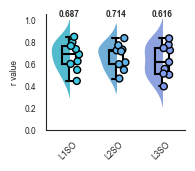

Summary statistics
L1SO: median=0.687, IQR=[0.600, 0.763], n=9
L2SO: median=0.714, IQR=[0.598, 0.730], n=9
L3SO: median=0.616, IQR=[0.512, 0.744], n=9

Wilcoxon signed-rank tests
  L1SO vs L2SO: p = 0.3594 ns
  L1SO vs L3SO: p = 0.0039 **
  L2SO vs L3SO: p = 0.0742 ns


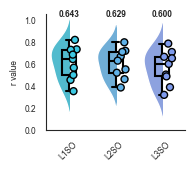

Summary statistics
L1SO: median=0.643, IQR=[0.499, 0.728], n=9
L2SO: median=0.629, IQR=[0.520, 0.709], n=9
L3SO: median=0.600, IQR=[0.486, 0.664], n=9

Wilcoxon signed-rank tests
  L1SO vs L2SO: p = 0.9102 ns
  L1SO vs L3SO: p = 0.0039 **
  L2SO vs L3SO: p = 0.0195 *


In [12]:
band = 'high_gamma'
sheet_dict = {
    'overt':"Ext. Fig. 9g",
    'covert':"Ext. Fig. 9h",
}
for task in sheet_dict.keys():
    sheet_name = sheet_dict[task]

    # =====================================================
    # Read the Source Data workbook.
    # =====================================================

    source_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )

    mean_acc_df = (
        source_df.rename(columns={
            "Subject": "HS",
            "Condition": "group",
            "Correlation (r)": "acc"
        })
    )

    # =====================================================
    # Create the plot.
    # =====================================================

    group_order = ["L1SO", "L2SO", "L3SO"]
    x_tick = ["L1SO", "L2SO", "L3SO"]

    palette = [
        "#3DC9E3",
        "#5FB1E8",
        "#7F9BED"
    ]

    plt.figure(figsize=(1.8, 1.5))
    sns.set_style("white")

    ax = sns.violinplot(
        x="group",
        y="acc",
        data=mean_acc_df,
        order=group_order,
        palette=palette,
        scale="width",
        inner=None,
        linewidth=1
    )

    sns.despine()

    # Draw the half-violin distribution.
    for violin in ax.collections:
        bbox = violin.get_paths()[0].get_extents()
        x0, y0, width, height = bbox.bounds
        violin.set_clip_path(
            plt.Rectangle(
                (x0, y0),
                width / 2,
                height,
                transform=ax.transData
            )
        )
        violin.set_edgecolor(None)

    # Overlay the boxplot.
    sns.boxplot(
        x="group",
        y="acc",
        data=mean_acc_df,
        order=group_order,
        width=0.3,
        showfliers=False,
        saturation=1,
        ax=ax,
        boxprops=dict(
            zorder=3,
            facecolor="none",
            edgecolor="black"
        ),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black")
    )

    # Plot individual participant values.
    old_len = len(ax.collections)

    sns.stripplot(
        x="group",
        y="acc",
        data=mean_acc_df,
        order=group_order,
        palette=palette,
        size=5,
        edgecolor="black",
        linewidth=1,
        ax=ax
    )

    for dots in ax.collections[old_len:]:
        dots.set_offsets(
            dots.get_offsets() + np.array([0.12, 0])
        )

    # =====================================================
    # Add median-value labels.
    # =====================================================

    for i, grp in enumerate(group_order):

        median = mean_acc_df.loc[
            mean_acc_df.group == grp,
            "acc"
        ].median()

        ax.text(
            i,
            1.01,
            f"{median:.3f}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold"
        )

    # =====================================================
    # Apply figure formatting.
    # =====================================================

    plt.ylim(0.0, 1.05)

    ax.set_ylabel("r value")
    ax.set_xlabel("")

    ticks = np.arange(len(group_order))
    ax.set_xticks(ticks + 0.2)
    ax.set_xticklabels(
        x_tick,
        rotation=45,
        ha="right"
    )

    plt.savefig(
        clean_data_path + f"figures_R3/{sheet_name}.pdf",
        transparent=True,
        bbox_inches="tight"
    )

    plt.show()

    # =====================================================
    # Calculate statistical tests.
    # =====================================================

    print("Summary statistics")

    for grp in group_order:

        values = mean_acc_df.loc[
            mean_acc_df.group == grp,
            "acc"
        ]

        median = values.median()
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)

        print(
            f"{grp}: "
            f"median={median:.3f}, "
            f"IQR=[{q1:.3f}, {q3:.3f}], "
            f"n={len(values)}"
        )

    print("\nWilcoxon signed-rank tests")

    pivot_df = mean_acc_df.pivot(
        index="HS",
        columns="group",
        values="acc"
    )

    pairs = list(itertools.combinations(group_order, 2))
    raw_p = []

    for group1, group2 in pairs:
        sub_df = mean_acc_df.pivot_table(index='HS', columns='group', values='acc')

        if group1 in sub_df.columns and group2 in sub_df.columns:
            paired_df = sub_df[[group1, group2]].dropna()
            data1, data2 = paired_df[group1], paired_df[group2]
            if len(data1) > 0:
                stat, p = wilcoxon(data1, data2)
                p_values.append(p)
                sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
                print(f"  {group1} vs {group2}: p = {p:.4f} {sig}")

#     # FDR correction
#     if p_values:
#         _, p_fdr, _, _ = multipletests(p_values, method='fdr_bh')
#         print("\nFDR-corrected:")
#         for i, (group1, group2) in enumerate(pairs):
#             sig_fdr = "***" if p_fdr[i] < 0.001 else "**" if p_fdr[i] < 0.01 else "*" if p_fdr[i] < 0.05 else "ns"
#             print(f"  {group1} vs {group2}: p_FDR = {p_fdr[i]:.4f} {sig_fdr}")


In [13]:
def leave_syllable_out_akt_decoding(group,band,figsize,syllable_order,sheet_name):
    # =====================================================
    # Read the Source Data workbook.
    # =====================================================

    source_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )

    mean_acc_df = (
        source_df[source_df["Type"] == "Observed"]
        .rename(columns={
            "Subject": "HS",
            "Task": "task",
            "Syllable": "syllable",
            "Correlation (r)": "acc"
        })
    )
    
    fig_save_path = clean_data_path + f"figures_R3/{sheet_name}.pdf"

    chance_mean_acc_df = (
        source_df[source_df["Type"] == "Chance"]
        .rename(columns={
            "Subject": "HS",
            "Task": "task",
            "Syllable": "syllable",
            "Correlation (r)": "acc"
        })
    )

    palette = {
        'SA': '#D5645B',
        'SI': '#88BBDF'
    }

    # =====================================================
    # Create the plot.
    # =====================================================

    plt.figure(figsize=figsize)

    sns.set_style('white')

    ax = sns.violinplot(
        x="syllable",
        y="acc",
        hue="task",
        data=mean_acc_df,
        dodge=True,
        split=True,
        palette=palette,
        scale="width",
        inner=None,
        linewidth=0,
        order=syllable_order
    )

    sns.boxplot(
        x="syllable",
        y="acc",
        hue="task",
        data=mean_acc_df,
        dodge=True,
        saturation=1,
        showfliers=False,
        width=0.3,
        ax=ax,
        order=syllable_order,
        boxprops={
            'zorder': 2,
            'facecolor': 'none',
            'edgecolor': 'k',
            'linewidth': 0.5
        },
        whiskerprops={'color': 'k', 'linewidth': 0.5},
        capprops={'color': 'k', 'linewidth': 0.5},
        medianprops={'color': 'k', 'linewidth': 0.5}
    )

    # Overlay chance-level boxplots.

    sns.boxplot(
        x="syllable",
        y="acc",
        hue="task",
        data=chance_mean_acc_df,
        dodge=True,
        saturation=1,
        showfliers=False,
        width=0.3,
        ax=ax,
        order=syllable_order,
        boxprops={
            'zorder': 2,
            'facecolor': 'none',
            'edgecolor': 'red',
            'linewidth': 0.5
        },
        whiskerprops={'color': 'red', 'linewidth': 0.5},
        capprops={'color': 'red', 'linewidth': 0.5},
        medianprops={'color': 'red', 'linewidth': 0.5}
    )

    sns.stripplot(
        x="syllable",
        y="acc",
        hue="task",
        data=mean_acc_df,
        dodge=True,
        palette=palette,
        size=3,
        edgecolor='black',
        linewidth=0.5,
        ax=ax,
        order=syllable_order
    )

    # =====================================================
    # Run the statistical analysis.
    # =====================================================

    significance_annotations = []

    for task in mean_acc_df['task'].unique():

        for syllable in mean_acc_df['syllable'].unique():

            # Compare the SA and SI conditions.

            a = mean_acc_df[
                (mean_acc_df['task'] == 'SA') &
                (mean_acc_df['syllable'] == syllable)
            ]['acc']

            b = mean_acc_df[
                (mean_acc_df['task'] == 'SI') &
                (mean_acc_df['syllable'] == syllable)
            ]['acc']

            stat, p_value = mannwhitneyu(a, b)

            print(
                f"\nBetween modalities: "
                f"Syllable = {syllable} | "
                f"U = {stat}, p = {p_value}"
            )

            # Compare each condition with chance level.

            mean_acc_values = mean_acc_df[
                (mean_acc_df['task'] == task) &
                (mean_acc_df['syllable'] == syllable)
            ]['acc']

            chance_acc_values = chance_mean_acc_df[
                (chance_mean_acc_df['task'] == task) &
                (chance_mean_acc_df['syllable'] == syllable)
            ]['acc']

            stat, p_value = mannwhitneyu(
                mean_acc_values,
                chance_acc_values,
                alternative='two-sided'
            )

            print(
                f"Task = {task}, "
                f"Syllable = {syllable} | "
                f"U = {stat}, p = {p_value}"
            )

            if p_value < 0.0001:
                significance_annotations.append((task, syllable, "****"))
            elif p_value < 0.001:
                significance_annotations.append((task, syllable, "***"))
            elif p_value < 0.01:
                significance_annotations.append((task, syllable, "**"))
            elif p_value < 0.05:
                significance_annotations.append((task, syllable, "*"))

    # =====================================================
    # Add statistical-significance annotations.
    # =====================================================

    for task, syllable, annotation in significance_annotations:

        x = syllable_order.index(syllable) + (
            0.15 if task == 'SI' else -0.15
        )

        y = max(
            mean_acc_df['acc'].max(),
            chance_mean_acc_df['acc'].max()
        ) + (0.08 if task == 'SI' else 0.13)

        ax.text(
            x,
            y,
            annotation,
            ha='center',
            va='bottom',
            fontsize=10,
            color='black'
        )

    # =====================================================
    # Apply figure formatting.
    # =====================================================

    sns.despine()

    plt.legend([], [], frameon=False)

    plt.ylim(-0.2, 1.02)

    ax.set_ylabel("r value")
    ax.set_xlabel("")

    ax.get_legend().remove()

    ticks = np.arange(len(syllable_order))

    ax.set_xticks(ticks + 0.2)
    ax.set_xticklabels(
        syllable_order,
        rotation=45,
        ha="right"
    )

    plt.savefig(
        fig_save_path,
        transparent=True,
        format="pdf",
        bbox_inches='tight'
    )

    plt.show()


# Fig. 5p


Between modalities: Syllable = ba | U = 49.0, p = 0.47992869214595724
Task = SA, Syllable = ba | U = 81.0, p = 0.00041229480206169127

Between modalities: Syllable = bu | U = 15.0, p = 0.6904761904761905
Task = SA, Syllable = bu | U = 25.0, p = 0.007936507936507936

Between modalities: Syllable = da | U = 48.0, p = 0.5364994693194564
Task = SA, Syllable = da | U = 81.0, p = 0.00041229480206169127

Between modalities: Syllable = du | U = 19.0, p = 0.2222222222222222
Task = SA, Syllable = du | U = 25.0, p = 0.007936507936507936

Between modalities: Syllable = ga | U = 49.0, p = 0.47992869214595724
Task = SA, Syllable = ga | U = 81.0, p = 0.00041229480206169127

Between modalities: Syllable = gu | U = 17.0, p = 0.42063492063492064
Task = SA, Syllable = gu | U = 25.0, p = 0.007936507936507936

Between modalities: Syllable = ka | U = 9.0, p = 0.8857142857142857
Task = SA, Syllable = ka | U = 16.0, p = 0.02857142857142857

Between modalities: Syllable = pa | U = 13.0, p = 0.2
Task = SA, Syl

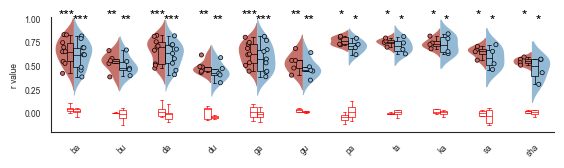

In [14]:
# =====================================================
# Define the analysis parameters.
# =====================================================

sheet_name = 'Fig. 5p'
group = 'sig_elecs_infer'
band = 'beta1'
figsize = (6.5, 1.5)

syllable_order = [
    'ba', 'bu', 'da', 'du', 'ga', 'gu',
    'pa', 'ta', 'ka', 'sa', 'sha'
]

leave_syllable_out_akt_decoding(group,band,figsize,syllable_order,sheet_name)


# Ext. Fig. 8f


Between modalities: Syllable = ('ba', 'bu') | U = 14.0, p = 0.8412698412698413
Task = SA, Syllable = ('ba', 'bu') | U = 25.0, p = 0.007936507936507936

Between modalities: Syllable = ('ba', 'da', 'ga') | U = 47.0, p = 0.5962416305866567
Task = SA, Syllable = ('ba', 'da', 'ga') | U = 81.0, p = 0.00041229480206169127

Between modalities: Syllable = ('bu', 'du', 'gu') | U = 13.0, p = 1.0
Task = SA, Syllable = ('bu', 'du', 'gu') | U = 25.0, p = 0.007936507936507936

Between modalities: Syllable = ('da', 'du') | U = 13.0, p = 1.0
Task = SA, Syllable = ('da', 'du') | U = 25.0, p = 0.007936507936507936

Between modalities: Syllable = ('ga', 'gu') | U = 18.0, p = 0.30952380952380953
Task = SA, Syllable = ('ga', 'gu') | U = 25.0, p = 0.007936507936507936

Between modalities: Syllable = ('ba', 'pa') | U = 13.0, p = 0.2
Task = SA, Syllable = ('ba', 'pa') | U = 16.0, p = 0.02857142857142857

Between modalities: Syllable = ('da', 'ta') | U = 9.0, p = 0.8857142857142857
Task = SA, Syllable = ('da',

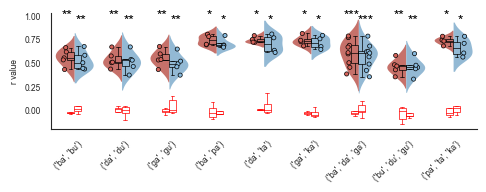

In [15]:
# =====================================================
# Define the analysis parameters.
# =====================================================

sheet_name = 'Ext. Fig. 8f'
group = 'sig_elecs_infer'
band = 'beta1'
figsize = (5.5, 1.5)

syllable_order = ["('ba', 'bu')", "('da', 'du')", "('ga', 'gu')", 
                  "('ba', 'pa')", "('da', 'ta')", "('ga', 'ka')",
                  "('ba', 'da', 'ga')", "('bu', 'du', 'gu')","('pa', 'ta', 'ka')"]

leave_syllable_out_akt_decoding(group,band,figsize,syllable_order,sheet_name)


# Ext. Fig. 9f


Between modalities: Syllable = ('ba', 'bu') | U = 19.0, p = 0.2222222222222222
Task = SA, Syllable = ('ba', 'bu') | U = 25.0, p = 0.007936507936507936

Between modalities: Syllable = ('ba', 'da', 'ga') | U = 53.0, p = 0.28931483238198774
Task = SA, Syllable = ('ba', 'da', 'ga') | U = 81.0, p = 0.00041229480206169127

Between modalities: Syllable = ('bu', 'du', 'gu') | U = 18.0, p = 0.30952380952380953
Task = SA, Syllable = ('bu', 'du', 'gu') | U = 25.0, p = 0.007936507936507936

Between modalities: Syllable = ('da', 'du') | U = 16.0, p = 0.5476190476190477
Task = SA, Syllable = ('da', 'du') | U = 25.0, p = 0.007936507936507936

Between modalities: Syllable = ('ga', 'gu') | U = 17.0, p = 0.42063492063492064
Task = SA, Syllable = ('ga', 'gu') | U = 25.0, p = 0.007936507936507936

Between modalities: Syllable = ba | U = 54.0, p = 0.25099827044292256
Task = SA, Syllable = ba | U = 81.0, p = 0.00041229480206169127

Between modalities: Syllable = bu | U = 19.0, p = 0.2222222222222222
Task =

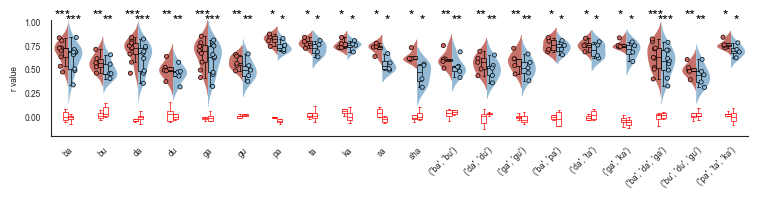

In [16]:
# =====================================================
# Define the analysis parameters.
# =====================================================

sheet_name = 'Ext. Fig. 9f'
group = 'sig_elecs_infer'
band = 'high_gamma'
figsize = (9, 1.5)

syllable_order = ['ba','bu','da','du','ga','gu','pa','ta','ka','sa','sha',
                  "('ba', 'bu')", "('da', 'du')", "('ga', 'gu')", 
                  "('ba', 'pa')", "('da', 'ta')", "('ga', 'ka')",
                  "('ba', 'da', 'ga')", "('bu', 'du', 'gu')","('pa', 'ta', 'ka')"]

leave_syllable_out_akt_decoding(group,band,figsize,syllable_order,sheet_name)


# Ext. Fig. 9d

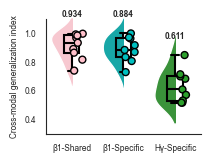

CMDG summary statistics:
β1-Shared: Median=0.934, Q1=0.865, Q3=0.984, N=9
β1-Specific: Median=0.884, Q1=0.835, Q3=0.964, N=9
Hγ-Specific: Median=0.611, Q1=0.534, Q3=0.701, N=9

Kruskal–Wallis test: H = 15.5062, p = 0.0004294

Pairwise Wilcoxon tests and one-sample tests:
                   Comparison     Raw p     FDR p  Significant
0    β1-Shared vs β1-Specific  0.039062  0.039062         True
1    β1-Shared vs Hγ-Specific  0.003906  0.005859         True
2  β1-Specific vs Hγ-Specific  0.003906  0.005859         True


In [17]:
# =====================================================
# Read the Source Data workbook.
# =====================================================

source_df = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Ext. Fig. 9d"
)

plot_df = source_df.rename(columns={
    "Subject": "HS",
    "Group": "group",
    "Cross-modal generalization index": "CMDG"
})

order = [
    "β1-Shared",
    "β1-Specific",
    "Hγ-Specific"
]

palette = [
    "Pink",
    "c",
    "#2ca02c"
]

# =====================================================
# Create the plot.
# =====================================================

plt.figure(figsize=(2, 1.5))

sns.set_style("white")

ax = sns.violinplot(
    x="group",
    y="CMDG",
    data=plot_df,
    order=order,
    dodge=False,
    palette=palette,
    scale="width",
    inner=None,
    linewidth=1
)

sns.despine()
plt.legend([], [], frameon=False)

plt.ylim(0.3, 1.1)

for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(
        Rectangle(
            (x0, y0),
            width / 2,
            height,
            transform=ax.transData
        )
    )
    violin.set_edgecolor(None)

sns.boxplot(
    x="group",
    y="CMDG",
    data=plot_df,
    order=order,
    saturation=1,
    showfliers=False,
    width=0.3,
    ax=ax,
    boxprops={
        "zorder": 3,
        "facecolor": "none",
        "edgecolor": "black"
    },
    whiskerprops={"color": "black"},
    capprops={"color": "black"},
    medianprops={"color": "black"}
)

old_len_collections = len(ax.collections)

sns.stripplot(
    x="group",
    y="CMDG",
    data=plot_df,
    order=order,
    palette=palette,
    dodge=False,
    ax=ax,
    size=5,
    edgecolor="black",
    linewidth=1
)

for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(
        dots.get_offsets() + np.array([0.12, 0])
    )

# Display the group medians.

group_medians = plot_df.groupby("group")["CMDG"].median()

for i, grp in enumerate(order):

    median_val = group_medians[grp]

    max_val = plot_df[
        plot_df["group"] == grp
    ]["CMDG"].max()

    ax.text(
        i,
        max_val + 0.10,
        f"{median_val:.3f}",
        ha="center",
        va="bottom",
        fontsize=6,
        fontweight="bold"
    )

ax.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1
)

ax.set_ylabel("Cross-modal generalization index")
ax.set_xlabel("")

plt.savefig(
    clean_data_path + "figures_R3/Ext. Fig. 9d.pdf",
    transparent=True,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# =====================================================
# Run the statistical analysis.
# =====================================================

cmdg_data = {
    grp: plot_df[
        plot_df["group"] == grp
    ][["HS", "CMDG"]].reset_index(drop=True)
    for grp in order
}

print("CMDG summary statistics:")

for grp in order:

    median = cmdg_data[grp]["CMDG"].median()
    q1 = cmdg_data[grp]["CMDG"].quantile(0.25)
    q3 = cmdg_data[grp]["CMDG"].quantile(0.75)

    print(
        f"{grp}: "
        f"Median={median:.3f}, "
        f"Q1={q1:.3f}, "
        f"Q3={q3:.3f}, "
        f"N={len(cmdg_data[grp])}"
    )

# =====================================================
# Run the Kruskal-Wallis test.
# =====================================================

H, p_overall = kruskal(
    cmdg_data["β1-Shared"]["CMDG"],
    cmdg_data["β1-Specific"]["CMDG"],
    cmdg_data["Hγ-Specific"]["CMDG"]
)

print(
    f"\nKruskal–Wallis test: "
    f"H = {H:.4f}, "
    f"p = {p_overall:.4g}"
)

# =====================================================
# Run pairwise Wilcoxon signed-rank tests.
# =====================================================

results = []

pairs = [
    (
        "β1-Shared vs β1-Specific",
        cmdg_data["β1-Shared"]["CMDG"],
        cmdg_data["β1-Specific"]["CMDG"]
    ),
    (
        "β1-Shared vs Hγ-Specific",
        cmdg_data["β1-Shared"]["CMDG"],
        cmdg_data["Hγ-Specific"]["CMDG"]
    ),
    (
        "β1-Specific vs Hγ-Specific",
        cmdg_data["β1-Specific"]["CMDG"],
        cmdg_data["Hγ-Specific"]["CMDG"]
    )
]

for name, a, b in pairs:

    stat, p = wilcoxon(a, b)

    results.append((name, p))

reject, pvals_fdr, _, _ = multipletests(
    [r[1] for r in results],
    method="fdr_bh"
)

results_df = pd.DataFrame({
    "Comparison": [r[0] for r in results],
    "Raw p": [r[1] for r in results],
    "FDR p": pvals_fdr,
    "Significant": reject
})

print("\nPairwise Wilcoxon tests and one-sample tests:")
print(results_df)


# Ext. Fig. 9c, SA and SI tasks

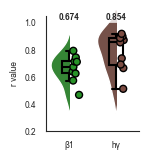


--- Descriptive Statistics ---
beta1: median = 0.674, IQR = [0.625, 0.714], n = 9
high_gamma: median = 0.854, IQR = [0.691, 0.886], n = 9

--- Pairwise Comparisons (Wilcoxon signed-rank test) ---
beta1 vs high_gamma: p = 0.0039 **


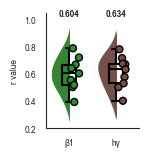


--- Descriptive Statistics ---
beta1: median = 0.604, IQR = [0.519, 0.668], n = 9
high_gamma: median = 0.634, IQR = [0.531, 0.675], n = 9

--- Pairwise Comparisons (Wilcoxon signed-rank test) ---
beta1 vs high_gamma: p = 0.0977 ns


In [18]:
group = 'sig_elecs'

for task in ['overt', 'covert']:

    band_order = ['beta1', 'high_gamma']
    x_tict = ['β1', 'hγ']
    figsize = (1.2, 1.5)

    sheet_name = {
        "overt": "Ext. Fig. 9c_SA",
        "covert": "Ext. Fig. 9c_SI"
    }[task]

    source_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name
    )

    mean_acc_df = source_df.rename(columns={
        "Subject": "HS",
        "Band": "band",
        "Correlation (r)": "acc"
    })

    palette = ["#289228", "#7c4c42"]

    iris = mean_acc_df
    order = band_order

    plt.figure(figsize=figsize)
    sns.set_style("white")

    ax = sns.violinplot(
        x="band",
        y="acc",
        data=iris,
        order=order,
        dodge=False,
        palette=palette,
        scale="width",
        inner=None,
        linewidth=1
    )

    sns.despine()
    plt.legend([], [], frameon=False)
    plt.ylim(-0.2, 1.02)

    for violin in ax.collections:
        bbox = violin.get_paths()[0].get_extents()
        x0, y0, width, height = bbox.bounds
        violin.set_clip_path(
            plt.Rectangle(
                (x0, y0),
                width / 2,
                height,
                transform=ax.transData
            )
        )
        violin.set_edgecolor(None)

    sns.boxplot(
        x="band",
        y="acc",
        data=iris,
        order=order,
        saturation=1,
        showfliers=False,
        width=0.3,
        ax=ax,
        boxprops={
            "zorder": 3,
            "facecolor": "none",
            "edgecolor": "black"
        },
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        medianprops={"color": "black"}
    )

    old_len_collections = len(ax.collections)

    sns.stripplot(
        x="band",
        y="acc",
        data=iris,
        order=order,
        palette=palette,
        dodge=False,
        ax=ax,
        size=5,
        edgecolor="black",
        linewidth=1
    )

    for dots in ax.collections[old_len_collections:]:
        dots.set_offsets(
            dots.get_offsets() + np.array([0.12, 0])
        )

    medians = []

    for band in band_order:
        median_val = np.median(
            iris.loc[iris["band"] == band, "acc"]
        )
        medians.append(median_val)

    for i, median_val in enumerate(medians):

        ax.text(
            i,
            1.01,
            f"{median_val:.3f}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0.8,
                edgecolor="none"
            )
        )

    sns.despine()
    plt.legend([], [], frameon=False)

    plt.ylim(0.2, 1.05)

    ax.set_ylabel("r value")
    ax.set_xlabel("")
    ax.get_legend().remove()

    ax.set_xticklabels(x_tict)

    fig_save_path = {
        "overt": clean_data_path + "figures_R3/Ext. Fig. 9c_SA.pdf",
        "covert": clean_data_path + "figures_R3/Ext. Fig. 9c_SI.pdf"
    }[task]

    plt.savefig(
        fig_save_path,
        transparent=True,
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()

    print("\n--- Descriptive Statistics ---")

    for band in band_order:

        data = iris.loc[iris["band"] == band, "acc"]

        median = np.median(data)
        q1, q3 = np.percentile(data, [25, 75])

        print(
            f"{band}: "
            f"median = {median:.3f}, "
            f"IQR = [{q1:.3f}, {q3:.3f}], "
            f"n = {len(data)}"
        )

    print("\n--- Pairwise Comparisons (Wilcoxon signed-rank test) ---")

    pairs = list(itertools.combinations(band_order, 2))
    p_values = []

    pivot_df = mean_acc_df.pivot(
        index="HS",
        columns="band",
        values="acc"
    )

    for band1, band2 in pairs:

        if band1 in pivot_df.columns and band2 in pivot_df.columns:

            valid = pivot_df[[band1, band2]].dropna()

            if len(valid) > 0:

                stat, p = wilcoxon(
                    valid[band1],
                    valid[band2],
                    alternative="two-sided"
                )

                p_values.append(p)

                sig = (
                    "***" if p < 0.001 else
                    "**" if p < 0.01 else
                    "*" if p < 0.05 else
                    "ns"
                )

                print(
                    f"{band1} vs {band2}: "
                    f"p = {p:.4f} {sig}"
                )
